# Walmart Sales Analysis

## This project analyzes Walmart weekly sales data to identify sales trends, top-performing stores, and the impact of holidays and external factors on sales.

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("D:\DS\Walmart_Sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [133]:
#Data Cleaning
#found out dataset has no missing|null values
#converted Date column from string to DateTime format,so that pandas can analyse date and time trends

In [134]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [135]:
df['Date']=pd.to_datetime(df['Date'],format='%d-%m-%Y')

In [136]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


# EDA


1. **Sales by Store**
2. **Sales trend based on Date**
3. **Sales trend based on holidays ->(0-normal,1-holiday)**
4. **Correlation[ Weekly_Sales,Temperature,Fuel_Price]**

In [137]:
df['Weekly_Sales'].sum()

np.float64(6737218987.11)

In [138]:
## Sales by stores

In [139]:
df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
19    2.066349e+08
31    1.996139e+08
23    1.987506e+08
24    1.940160e+08
11    1.939628e+08
28    1.892637e+08
41    1.813419e+08
32    1.668192e+08
18    1.551147e+08
22    1.470756e+08
12    1.442872e+08
26    1.434164e+08
34    1.382498e+08
40    1.378703e+08
35    1.315207e+08
8     1.299512e+08
17    1.277821e+08
45    1.123953e+08
21    1.081179e+08
25    1.010612e+08
43    9.056544e+07
15    8.913368e+07
7     8.159828e+07
42    7.956575e+07
9     7.778922e+07
29    7.714155e+07
16    7.425243e+07
37    7.420274e+07
30    6.271689e+07
3     5.758674e+07
38    5.515963e+07
36    5.341221e+07
5     4.547569e+07
44    4.329309e+07
33    3.716022e+07
Name: Weekly_Sales, dtype: float64

In [140]:
## overall sales on all stores grouped by date

In [141]:
df.groupby('Date')['Weekly_Sales'].sum()

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
                 ...     
2012-09-28    43734899.40
2012-10-05    47566639.31
2012-10-12    46128514.25
2012-10-19    45122410.57
2012-10-26    45544116.29
Name: Weekly_Sales, Length: 143, dtype: float64

-February more sales -clearence sale its not because of holiday.also this is weekly sales sum of all stores,as few stores would have made discounts such as clearence sale which increased overall sales revenue accross all walmart stores.


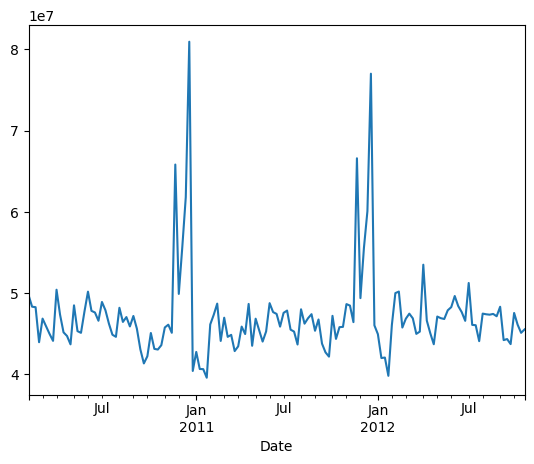

In [142]:
df.groupby('Date')['Weekly_Sales'].sum().plot()
plt.show()

-here you can see spike in december(holiday purchases)

In [143]:
## mean sales based on holiday flag

In [144]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

-On avg people buy more on holidays since mean is higher for holiday sales

In [145]:
## correlation factor[Weekly sales and Tempterature '-' relation ,Weekly sales and Fuel price '+' relation]

In [146]:
df[['Weekly_Sales','Temperature','Fuel_Price']].corr()

,Weekly_Sales,Temperature,Fuel_Price
Weekly_Sales,1.000000,-0.063810,0.009464
Temperature,-0.063810,1.000000,0.144982
Fuel_Price,0.009464,0.144982,1.000000


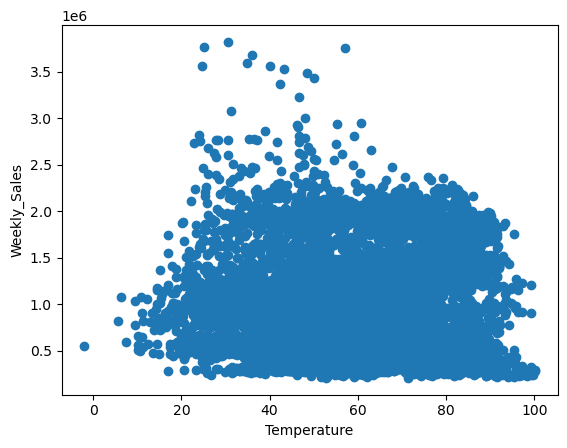

In [147]:
plt.scatter(df['Temperature'],df['Weekly_Sales'])
plt.xlabel('Temperature')
plt.ylabel('Weekly_Sales')
plt.show()

-As temperature increases, sales slightly decrease

-Fuel prices don’t strongly affect sales here

# visulalizing data

## Bar chart shows which store performs better

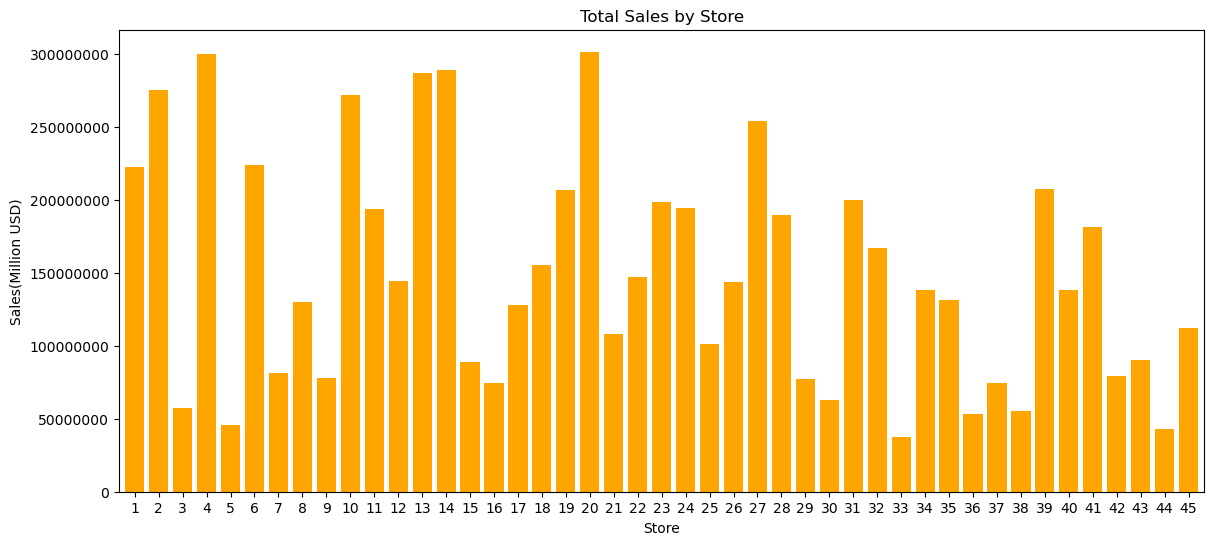

In [148]:
sales_by_store=df.groupby('Store')['Weekly_Sales'].sum()
plt.figure(figsize=(14,6))
sales_by_store.plot(kind='bar',color='orange',width=0.8)
plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Sales(Million USD)")
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain',axis='y')
plt.show()

-4,13,14,20 some of best performing stores

# Line Chart shows sales based on each store

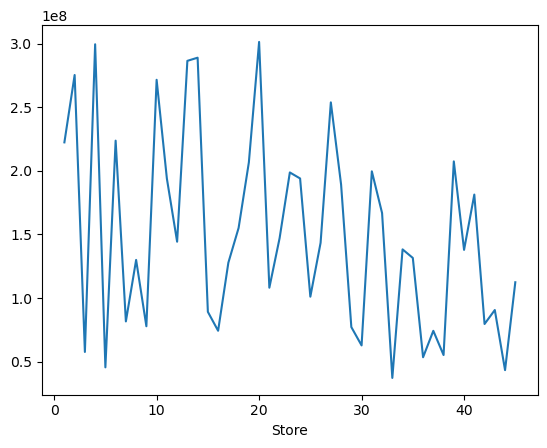

In [149]:
df.groupby('Store')['Weekly_Sales'].sum().plot(kind='line')
plt.show()

-Again proves stores such as 4,13,14,20 some of high sales

## Line chart to show sales over time

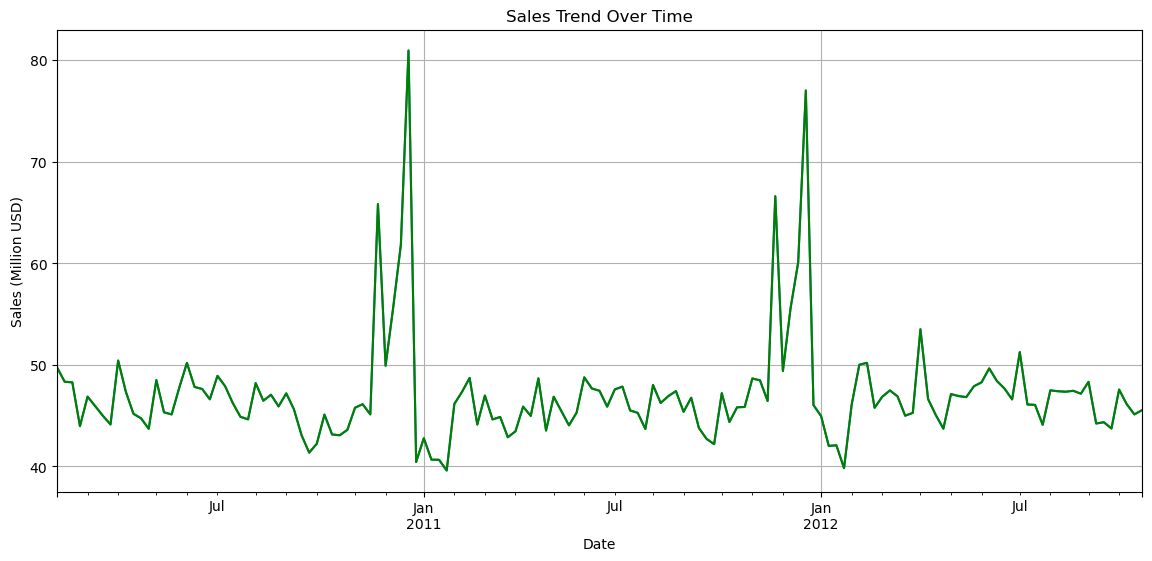

In [150]:
sales_over_time = df.groupby('Date')['Weekly_Sales'].sum() / 1_000_000
plt.show()
plt.figure(figsize=(14,6))
sales_over_time.plot()
sales_over_time.plot(
    kind='line',
    color='green'
)
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales (Million USD)")

plt.grid()

plt.show()


-We can clearly see spikes on december

## Box Plot (holiday vs non-holiday)

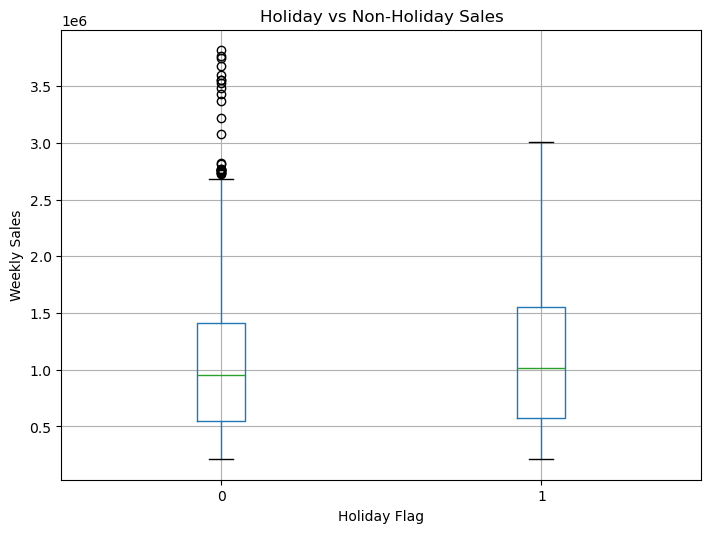

In [151]:
df.boxplot(column='Weekly_Sales', by='Holiday_Flag', figsize=(8,6))

plt.title("Holiday vs Non-Holiday Sales")
plt.suptitle("")

plt.xlabel("Holiday Flag")
plt.ylabel("Weekly Sales")

plt.show()

-This box plot shows that the median is higher in holiday(meaning more sales on avg) and also holiday box taller(sales vary a lot)

-Outliers are present in normal days(some nonrmal days perform very well)

In [152]:
df[df['Holiday_Flag'] == 0].sort_values(by='Weekly_Sales', ascending=False).head(10)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
1905,14,2010-12-24,3818686.45,0,30.59,3.141,182.544590,8.724
2763,20,2010-12-24,3766687.43,0,25.17,3.141,204.637673,7.484
1333,10,2010-12-24,3749057.69,0,57.06,3.236,126.983581,9.003
527,4,2011-12-23,3676388.98,0,35.92,3.103,129.984548,5.143
1762,13,2010-12-24,3595903.20,0,34.90,2.846,126.983581,7.795
1814,13,2011-12-23,3556766.03,0,24.76,3.186,129.984548,6.392
2815,20,2011-12-23,3555371.03,0,40.19,3.389,212.236040,7.082
475,4,2010-12-24,3526713.39,0,43.21,2.887,126.983581,7.127
1385,10,2011-12-23,3487986.89,0,48.36,3.541,129.984548,7.874
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.064660,8.163


-more stores have higher sales on dec on 23 24 on eve of holidays(last minuite purchases before holidays-christmas to be precise)

-Aggregate weekly sales analysis showed peak company-wide performance during February periods, while row-level analysis revealed exceptionally high individual store sales occurring primarily during December weeks, likely influenced by holiday shopping demand.


-Takeaway->Although holiday weeks show significant sales spikes, the presence of numerous outliers during non-holiday periods suggests that additional business factors such as promotions, regional demand, or store performance also influence weekly sales.

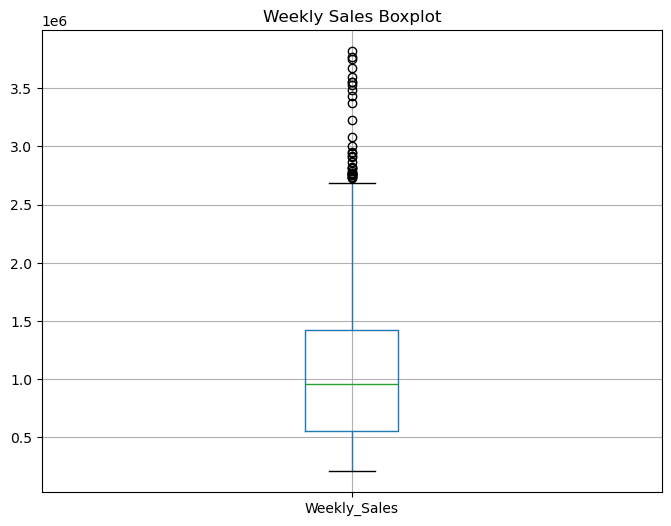

In [153]:
plt.figure(figsize=(8,6))

df.boxplot(column='Weekly_Sales')

plt.title("Weekly Sales Boxplot")

plt.show()


## Histogram showing Distribution of Weekly Sales

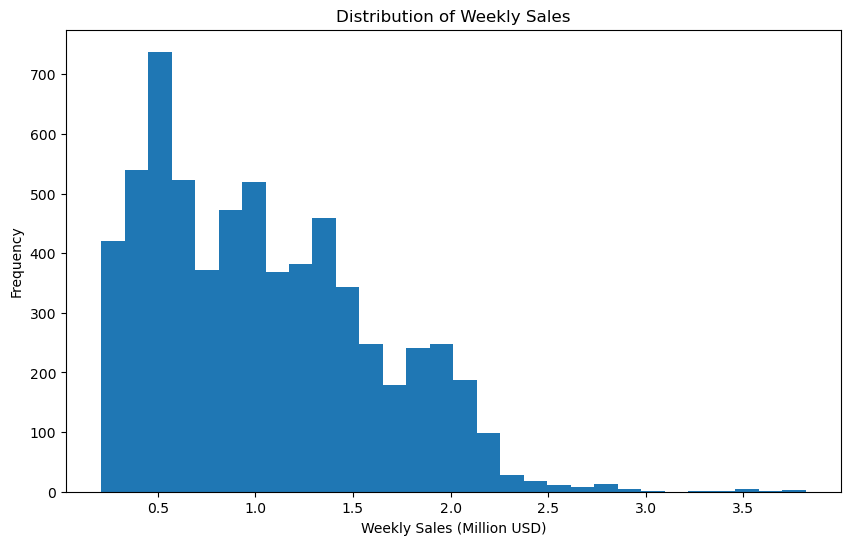

In [154]:
sales_million = df['Weekly_Sales'] / 1_000_000

plt.figure(figsize=(10,6))

sales_million.plot(kind='hist', bins=30)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales (Million USD)")
plt.ylabel("Frequency")


plt.show()

-most stores generate 0.3 million → 1.5 million which is the moderate sales by stats(tall bars concentrated here as you see)
-This is a Right Skewed distribution as most of the sales are low to moderate but also small number of extremely high sales are also seen

In [155]:
high_sales = df[df['Weekly_Sales'] > 3000000]

high_sales

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.064660,8.163
241,2,2011-12-23,3224369.80,0,46.66,3.112,218.999550,7.441
475,4,2010-12-24,3526713.39,0,43.21,2.887,126.983581,7.127
523,4,2011-11-25,3004702.33,1,47.96,3.225,129.836400,5.143
527,4,2011-12-23,3676388.98,0,35.92,3.103,129.984548,5.143
1333,10,2010-12-24,3749057.69,0,57.06,3.236,126.983581,9.003
1385,10,2011-12-23,3487986.89,0,48.36,3.541,129.984548,7.874
1762,13,2010-12-24,3595903.20,0,34.90,2.846,126.983581,7.795
1814,13,2011-12-23,3556766.03,0,24.76,3.186,129.984548,6.392
1905,14,2010-12-24,3818686.45,0,30.59,3.141,182.544590,8.724


In [156]:
high_sales[['Date', 'Store', 'Weekly_Sales', 'Holiday_Flag']]

,Date,Store,Weekly_Sales,Holiday_Flag
189,2010-12-24,2,3436007.68,0
241,2011-12-23,2,3224369.80,0
475,2010-12-24,4,3526713.39,0
523,2011-11-25,4,3004702.33,1
527,2011-12-23,4,3676388.98,0
1333,2010-12-24,10,3749057.69,0
1385,2011-12-23,10,3487986.89,0
1762,2010-12-24,13,3595903.20,0
1814,2011-12-23,13,3556766.03,0
1905,2010-12-24,14,3818686.45,0


In [157]:
high_sales['Store'].value_counts()

Store
4     3
2     2
10    2
13    2
14    2
20    2
27    1
Name: count, dtype: int64

-store 4 performs better and consistant as confirmed earlier

In [158]:
high_sales.sort_values(by='Weekly_Sales', ascending=False)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
1905,14,2010-12-24,3818686.45,0,30.59,3.141,182.544590,8.724
2763,20,2010-12-24,3766687.43,0,25.17,3.141,204.637673,7.484
1333,10,2010-12-24,3749057.69,0,57.06,3.236,126.983581,9.003
527,4,2011-12-23,3676388.98,0,35.92,3.103,129.984548,5.143
1762,13,2010-12-24,3595903.20,0,34.90,2.846,126.983581,7.795
1814,13,2011-12-23,3556766.03,0,24.76,3.186,129.984548,6.392
2815,20,2011-12-23,3555371.03,0,40.19,3.389,212.236040,7.082
475,4,2010-12-24,3526713.39,0,43.21,2.887,126.983581,7.127
1385,10,2011-12-23,3487986.89,0,48.36,3.541,129.984548,7.874
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.064660,8.163


-stores have higher sales on 23,24 dec

## correlation visualized using heatmap

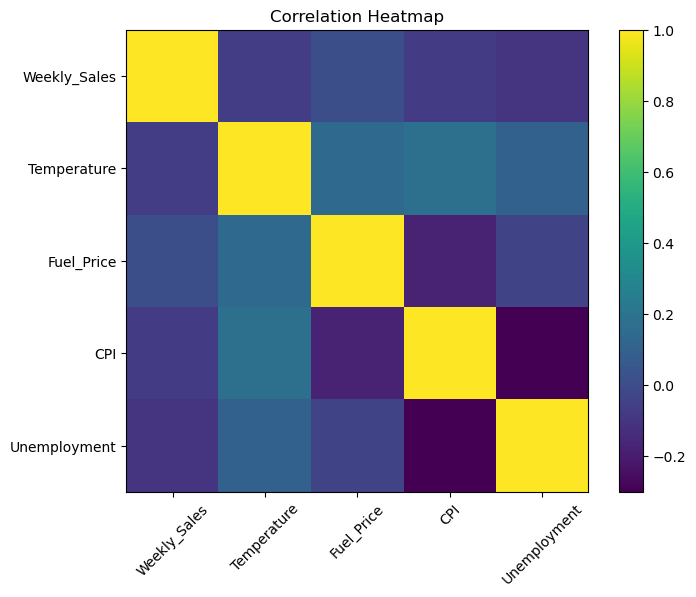

In [159]:
corr = df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

-The correlation heatmap indicates weak relationships between weekly sales and external economic factors such as temperature, fuel price, CPI, and unemployment, suggesting that these variables have limited direct linear influence on Walmart sales performance.


## Conclusion

- The analysis revealed that Stores 2, 4, 13, 14, and 20 were among the top-performing stores overall based on total weekly sales.

- Holiday weeks generally showed higher average sales; however, several non-holiday weeks also experienced significant sales spikes. This suggests that customers respond strongly not only to holidays but also to promotional events, discounts, and clearance sales.

- The sales distribution showed that exceptionally high sales occur occasionally, while most weeks maintain moderate sales levels, which reflects typical retail sales behavior.

- Store 4 and Store 20 demonstrated particularly strong and consistent performance. Both stores crossed the 3 million sales mark multiple times and frequently achieved weekly sales above 2 million, indicating stable customer demand and strong store performance over time.

- Correlation analysis indicated weak relationships between weekly sales and external economic factors such as temperature, fuel price, CPI, and unemployment. This suggests that Walmart sales remained relatively stable despite changes in these economic conditions.